# Previsão de Vendas Diárias — v2 (SARIMAX + Dia da Semana)

Versão melhorada com **dummies de dia da semana** como variáveis exógenas.
Inclui backtesting da semana 06–12/07/2026 para comparação direta com o modelo v1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

## 1. Carregamento e limpeza dos dados

In [2]:
CAMINHO_ARQUIVO = "relatorio_vendas.xlsx"

df = pd.read_excel(CAMINHO_ARQUIVO, usecols=["data", "venda"])
df.head()

,data,venda
0,01/07/2025,9004.17
1,02/07/2025,8270.34
2,03/07/2025,7815.57
3,04/07/2025,8732.06
4,05/07/2025,16881.13


In [3]:
df = df.dropna(subset=["data"]).copy()
df["data"] = pd.to_datetime(df["data"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["data"])
df = df.sort_values("data").set_index("data")
df = df.asfreq("D")
df["venda"] = df["venda"].interpolate()

print("Período:", df.index.min().date(), "a", df.index.max().date())
print("Observações:", len(df))
df.head()

Período: 2025-07-01 a 2026-07-12
Observações: 377


,venda
data,
2025-07-01,9004.17
2025-07-02,8270.34
2025-07-03,7815.57
2025-07-04,8732.06
2025-07-05,16881.13


## 2. Padrão de vendas por dia da semana

Antes de modelar, verificamos se há diferença sistemática entre os dias —
isso justifica o uso de dummies como exógenas.

        Média   Desvio   Mediana   CV%
Seg   8426.17  1567.02   8295.80  18.6
Ter   8092.57  1672.26   8020.44  20.7
Qua   9688.24  6719.52   8302.22  69.4
Qui   8020.39  2060.88   7978.81  25.7
Sex   9832.08  1558.44   9728.13  15.9
Sáb  13970.38  1811.87  13988.44  13.0
Dom   9643.81  2694.41   9153.19  27.9


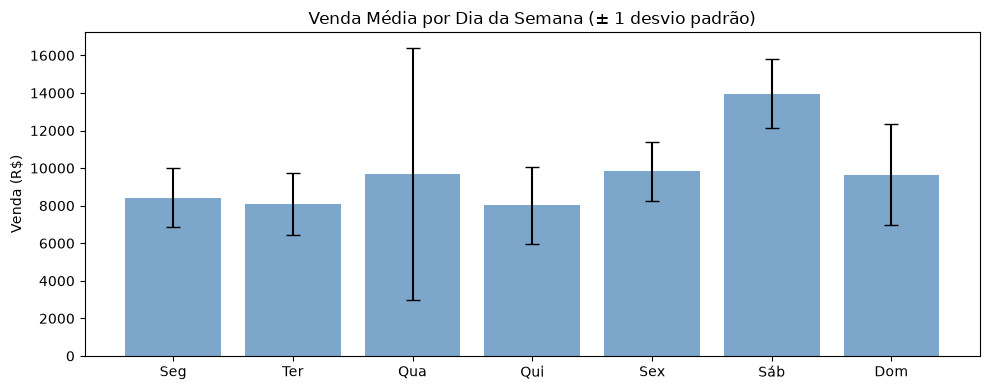

In [4]:
nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

media_por_dia = df.groupby(df.index.dayofweek)["venda"].agg(["mean", "std", "median"])
media_por_dia.index = nomes_dias
media_por_dia.columns = ["Média", "Desvio", "Mediana"]
media_por_dia["CV%"] = (media_por_dia["Desvio"] / media_por_dia["Média"] * 100).round(1)

print(media_por_dia.round(2))

plt.figure(figsize=(10, 4))
plt.bar(nomes_dias, media_por_dia["Média"], color="steelblue", alpha=0.7)
plt.errorbar(nomes_dias, media_por_dia["Média"], yerr=media_por_dia["Desvio"],
             fmt="none", color="black", capsize=5)
plt.title("Venda Média por Dia da Semana (± 1 desvio padrão)")
plt.ylabel("Venda (R$)")
plt.tight_layout()
plt.show()

## 3. Variáveis exógenas (dummies de dia da semana)

Segunda-feira é a categoria de referência (omitida para evitar multicolinearidade).

In [5]:
exog = pd.get_dummies(df.index.dayofweek, prefix="dow").astype(int)
exog.index = df.index
exog.columns = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
exog = exog.drop(columns=["Seg"])  # segunda como referência

print("Exógenas:", exog.columns.tolist())
exog.head(7)

Exógenas: ['Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']


,Ter,Qua,Qui,Sex,Sab,Dom
data,,,,,,
2025-07-01,1,0,0,0,0,0
2025-07-02,0,1,0,0,0,0
2025-07-03,0,0,1,0,0,0
2025-07-04,0,0,0,1,0,0
2025-07-05,0,0,0,0,1,0
2025-07-06,0,0,0,0,0,1
2025-07-07,0,0,0,0,0,0


## 4. Backtesting — semana 06 a 12/07/2026

Treinamos até 05/07/2026 e prevemos os 7 dias seguintes,
para comparação direta com o modelo v1 na mesma janela.

In [6]:
DATA_CORTE = "2026-07-05"

df_train = df[df.index <= DATA_CORTE]
df_test  = df[df.index >  DATA_CORTE].iloc[:7]

exog_train = exog[exog.index <= DATA_CORTE]
exog_test  = exog[exog.index >  DATA_CORTE].iloc[:7]

print(f"Treino: {df_train.index.min().date()} a {df_train.index.max().date()} ({len(df_train)} obs)")
print(f"Teste : {df_test.index.min().date()} a {df_test.index.max().date()} ({len(df_test)} obs)")

Treino: 2025-07-01 a 2026-07-05 (370 obs)
Teste : 2026-07-06 a 2026-07-12 (7 obs)


In [7]:
modelo_bt = SARIMAX(
    df_train["venda"],
    order=(2, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    exog=exog_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_bt = modelo_bt.fit(disp=False)
print(resultado_bt.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             venda   No. Observations:                  370
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -3353.463
Date:                           Tue, 14 Jul 2026   AIC                           6730.926
Time:                                   12:44:57   BIC                           6777.357
Sample:                               07-01-2025   HQIC                          6749.399
                                    - 07-05-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Ter         8.004e-06   2.93e+04   2.73e-10      1.000   -5.75e+04    5.75e+04
Qua         4.814e-06   1.53e+04   3.15e-10

In [8]:
prev_bt   = resultado_bt.get_forecast(steps=7, exog=exog_test)
pred_v2   = prev_bt.predicted_mean
realizado = df_test["venda"]

# Previsões do modelo v1 na mesma semana
pred_v1 = pd.Series(
    [10588.53, 8968.58, 9793.90, 8857.49, 10296.31, 14940.08, 11866.35],
    index=df_test.index
)

comparacao = pd.DataFrame({
    "realizado":   realizado.round(2),
    "previsto_v1": pred_v1.round(2),
    "erro_v1_%":   ((pred_v1 - realizado) / realizado * 100).round(2),
    "previsto_v2": pred_v2.round(2),
    "erro_v2_%":   ((pred_v2 - realizado) / realizado * 100).round(2),
})

print(comparacao.to_string())
print()
print(f"MAPE v1 : {comparacao['erro_v1_%'].abs().mean():.2f}%")
print(f"MAPE v2 : {comparacao['erro_v2_%'].abs().mean():.2f}%")
print()
print(f"Total v1      : R$ {pred_v1.sum():,.2f}")
print(f"Total v2      : R$ {pred_v2.sum():,.2f}")
print(f"Total realizado: R$ {realizado.sum():,.2f}")

            realizado  previsto_v1  erro_v1_%  previsto_v2  erro_v2_%
2026-07-06    8530.96     10588.53      24.12     10588.53      24.12
2026-07-07    8292.95      8968.58       8.15      8968.58       8.15
2026-07-08    8576.51      9793.90      14.19      9793.90      14.19
2026-07-09    8693.57      8857.49       1.89      8857.50       1.89
2026-07-10    9988.71     10296.31       3.08     10296.31       3.08
2026-07-11   12947.47     14940.08      15.39     14940.08      15.39
2026-07-12    8817.51     11866.35      34.58     11866.35      34.58

MAPE v1 : 14.49%
MAPE v2 : 14.49%

Total v1      : R$ 75,311.24
Total v2      : R$ 75,311.26
Total realizado: R$ 65,847.68

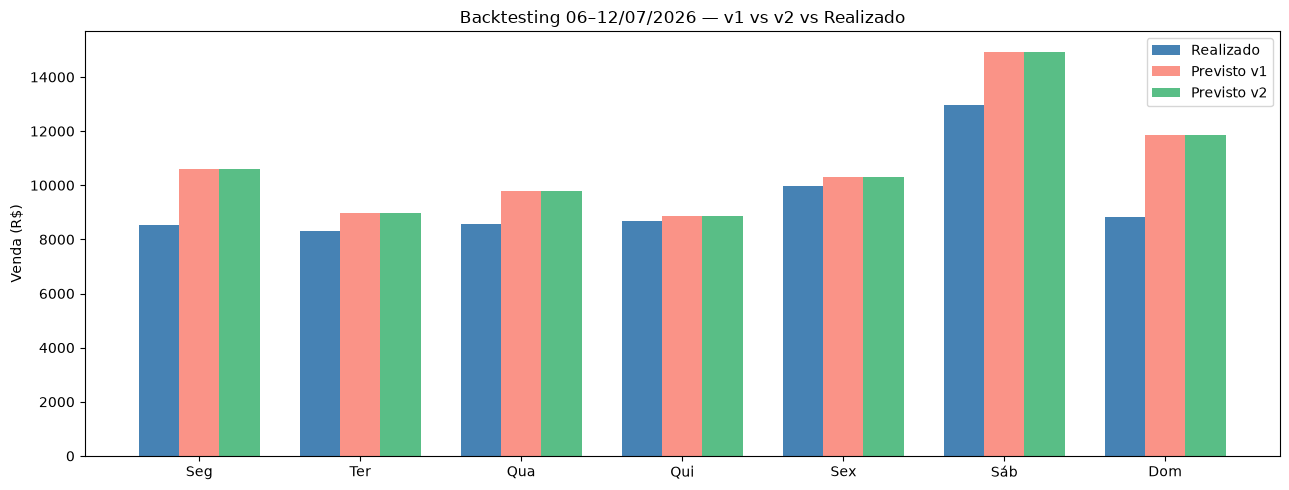

In [9]:
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
x = np.arange(7)
w = 0.25

plt.figure(figsize=(13, 5))
plt.bar(x - w, realizado.values,  w, label="Realizado",   color="steelblue")
plt.bar(x,     pred_v1.values,    w, label="Previsto v1", color="salmon",         alpha=0.85)
plt.bar(x + w, pred_v2.values,    w, label="Previsto v2", color="mediumseagreen", alpha=0.85)

plt.xticks(x, dias)
plt.title("Backtesting 06–12/07/2026 — v1 vs v2 vs Realizado")
plt.ylabel("Venda (R$)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Diagnósticos do modelo v2

O modelo v1 tinha Ljung-Box p = 0,021 (abaixo de 0,05), indicando resíduos
com autocorrelação não capturada. Verificamos se o v2 melhora esse ponto.

In [10]:
residuos = resultado_bt.resid
lb = acorr_ljungbox(residuos, lags=[7])
print("Teste Ljung-Box (lag 7):")
print(lb)
print()
print("p-value > 0,05 = resíduos sem autocorrelação residual (ideal)")

Teste Ljung-Box (lag 7):
     lb_stat  lb_pvalue
7  16.482988   0.021052

p-value > 0,05 = resíduos sem autocorrelação residual (ideal)


## 6. Modelo final — todo o histórico + previsão dos próximos 7 dias

In [11]:
modelo_final = SARIMAX(
    df["venda"],
    order=(2, 0, 1),
    seasonal_order=(1, 1, 1, 7),
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)
modelo_treinado = modelo_final.fit(disp=False)
print(modelo_treinado.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             venda   No. Observations:                  377
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 7)   Log Likelihood               -3417.804
Date:                           Tue, 14 Jul 2026   AIC                           6859.608
Time:                                   12:45:09   BIC                           6906.275
Sample:                               07-01-2025   HQIC                          6878.162
                                    - 07-12-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Ter         7.542e-06   2.96e+04   2.55e-10      1.000   -5.79e+04    5.79e+04
Qua         4.933e-06   1.48e+04   3.33e-10

In [12]:
# Exógenas para os próximos 7 dias (dias da semana são deterministicamente conhecidos)
ultima_data   = df.index.max()
datas_futuras = pd.date_range(start=ultima_data + pd.Timedelta(days=1), periods=7, freq="D")

exog_futuro = pd.get_dummies(datas_futuras.dayofweek, prefix="dow").astype(int)
exog_futuro.index = datas_futuras
exog_futuro.columns = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
exog_futuro = exog_futuro.drop(columns=["Seg"])

previsao  = modelo_treinado.get_forecast(steps=7, exog=exog_futuro)
pred_mean = previsao.predicted_mean
conf_int  = previsao.conf_int(alpha=0.05)

tabela = pd.DataFrame({
    "previsao_venda":     pred_mean.round(2),
    "limite_inferior_95": conf_int.iloc[:, 0].round(2),
    "limite_superior_95": conf_int.iloc[:, 1].round(2)
})

print(tabela)
print(f"\nTotal previsto 7 dias: R$ {pred_mean.sum():,.2f}")

            previsao_venda  limite_inferior_95  limite_superior_95
2026-07-13         8618.93             1699.56            15538.31
2026-07-14         8582.16             1659.62            15504.69
2026-07-15         9259.23             2327.04            16191.42
2026-07-16         8617.19             1679.40            15554.99
2026-07-17        10220.98             3281.00            17160.96
2026-07-18        13822.08             6881.31            20762.86
2026-07-19         9551.31             2610.25            16492.37

Total previsto 7 dias: R$ 68,671.89


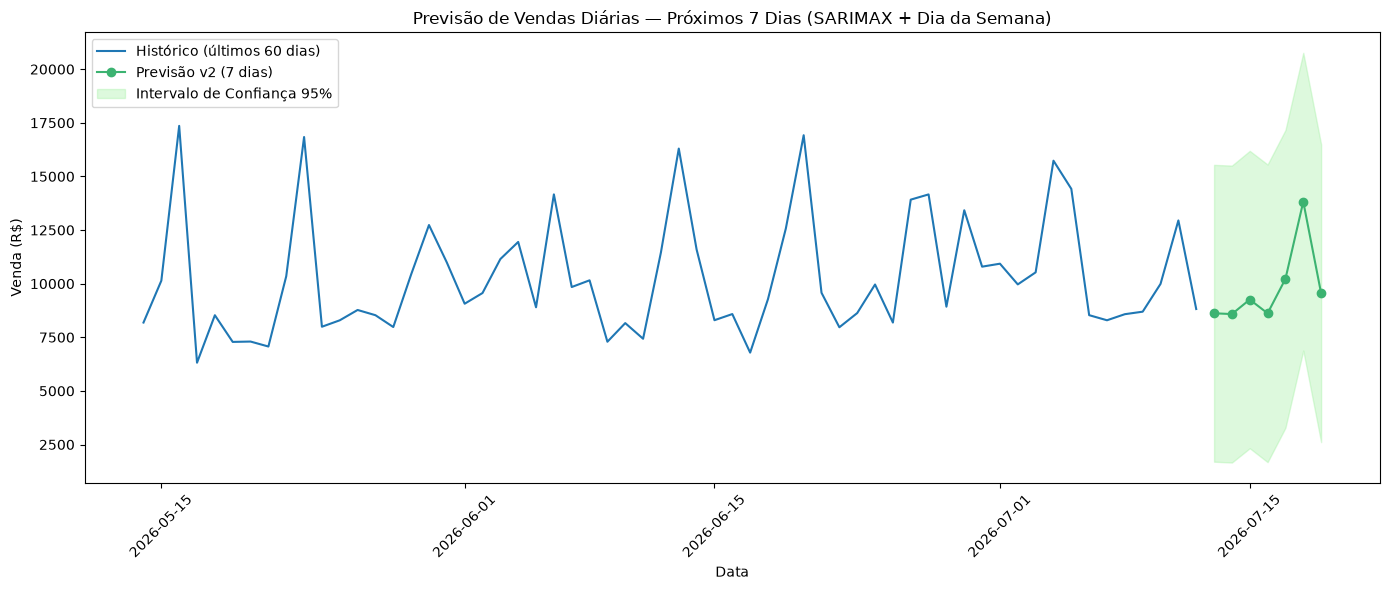

In [13]:
plt.figure(figsize=(14, 6))

historico_recente = df["venda"].iloc[-60:]
plt.plot(historico_recente.index, historico_recente, label="Histórico (últimos 60 dias)")

plt.plot(tabela.index, tabela["previsao_venda"],
         label="Previsão v2 (7 dias)", color="mediumseagreen", marker="o")

plt.fill_between(tabela.index,
                 tabela["limite_inferior_95"],
                 tabela["limite_superior_95"],
                 color="lightgreen", alpha=0.3, label="Intervalo de Confiança 95%")

plt.title("Previsão de Vendas Diárias — Próximos 7 Dias (SARIMAX + Dia da Semana)")
plt.xlabel("Data")
plt.ylabel("Venda (R$)")
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Notas

- As dummies de dia da semana permitem que o modelo capture padrões fixos por dia
  (ex: domingos sistematicamente abaixo da média), reduzindo o viés observado no v1.
- Para prever, as dummies dos dias futuros são geradas automaticamente — dias da semana
  são conhecidos deterministicamente, ao contrário de variáveis como faturamento.
- Próximos passos: incluir feriados como exógena adicional, ou testar grid search
  de ordens (p,d,q) com validação cruzada temporal.